# Análise Exploratória 1 - PCA (Análise de Componentes Principais)

Com o dataset perfeitamente tratado, aplicaremos o PCA para extrair as variâncias e gerar o gráfico 2D, respondendo às exigências metodológicas.

## 1. Importações e Configurações Visuais

In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## 2. Carregamento dos Dados da Camada Gold

In [24]:
# Como este notebook está dentro da pasta 'PCA', voltamos um nível para acessar o parquet
DATASET_PATH = '../formai_gold.parquet'

In [25]:
# Carregamento do dataset
df_gold = pd.read_parquet(DATASET_PATH)

print(f"Dataset carregado! Total de registros prontos para o PCA: {len(df_gold)}")

Dataset carregado! Total de registros prontos para o PCA: 791040


Separando as variáveis numéricas para a matriz X e as categóricas (alvo) para y

In [26]:
numeric_features = [
    'num_lines', 
    'cyclomatic_complexity', 
    'token_count', 
    'function_count', 
    'avg_parameter_count'
]

X = df_gold[numeric_features]
y = df_gold['category']

y.value_counts()

category
VULNERABLE        765366
NON-VULNERABLE     25674
Name: count, dtype: int64

## 3. Aplicação do Algoritmo PCA

### Instanciando e treinando o modelo PCA para gerar 2 componentes principais

In [28]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

X_pca

array([[-0.75291044, -0.41592262],
       [-0.75291044, -0.41592262],
       [-0.75291044, -0.41592262],
       ...,
       [-0.23454081,  0.68910767],
       [ 4.95934757,  0.81614709],
       [ 4.95934757,  0.81614709]], shape=(791040, 2))

### Criação de um novo DataFrame com as dimensões reduzidas para facilitar a plotagem

In [29]:
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['category'] = y.values

print("Transformação PCA concluída com sucesso.")
df_pca.head()

Transformação PCA concluída com sucesso.


,PC1,PC2,category
0,-0.752910,-0.415923,VULNERABLE
1,-0.752910,-0.415923,VULNERABLE
2,-0.752910,-0.415923,VULNERABLE
3,1.202637,-0.939876,VULNERABLE
4,1.202637,-0.939876,VULNERABLE


## 4. Análise da Variância e Peso das Features

(Esta célula extrai as respostas exatas para a sua documentação do trabalho sobre quais features influenciaram os componentes e se a variância foi suficiente).

In [31]:
var_explicada = pca.explained_variance_ratio_
print(f"Variância explicada pelo Componente Principal 1 (PC1): {var_explicada[0]*100:.2f}%")
print(f"Variância explicada pelo Componente Principal 2 (PC2): {var_explicada[1]*100:.2f}%")
print(f"Variância Total Acumulada no plano 2D: {var_explicada.sum()*100:.2f}%\n")

Variância explicada pelo Componente Principal 1 (PC1): 49.17%
Variância explicada pelo Componente Principal 2 (PC2): 29.29%
Variância Total Acumulada no plano 2D: 78.46%



In [32]:
df_components = pd.DataFrame(
    pca.components_, 
    columns=numeric_features, 
    index=['PC1 (Pesos / Autovetores)', 'PC2 (Pesos / Autovetores)']
)
print("Contribuição de cada variável original na construção dos Componentes Principais:")
display(df_components)

Contribuição de cada variável original na construção dos Componentes Principais:


,num_lines,cyclomatic_complexity,token_count,function_count,avg_parameter_count
PC1 (Pesos / Autovetores),0.562468,-0.088419,0.565634,0.516354,0.298744
PC2 (Pesos / Autovetores),0.309131,0.743562,0.301160,-0.300287,-0.413139


## 5. Salvar os resultados da transformação PCA

In [41]:
PCA_RESULTS_PATH = 'pca_results.parquet'
PCA_IMAGE_PATH = 'pca_plot.png'

In [43]:
print("Salvando os resultados do PCA no disco...")
df_pca.to_parquet(PCA_RESULTS_PATH, engine='pyarrow', index=False)

print(f"Resultados do MDS salvos com sucesso em: {os.path.abspath(PCA_RESULTS_PATH)}")

Salvando os resultados do PCA no disco...
Resultados do MDS salvos com sucesso em: /home/deus/Documents/UEA/7_periodo/data_sci/pca_mds/ai-and-sec-issues_data-lake/src/03_gold/PCA/pca_results.parquet


### Plotagem Bidimensional do PCA + Gravação do gráfico

Gerando e exportando o gráfico do PCA em PNG...


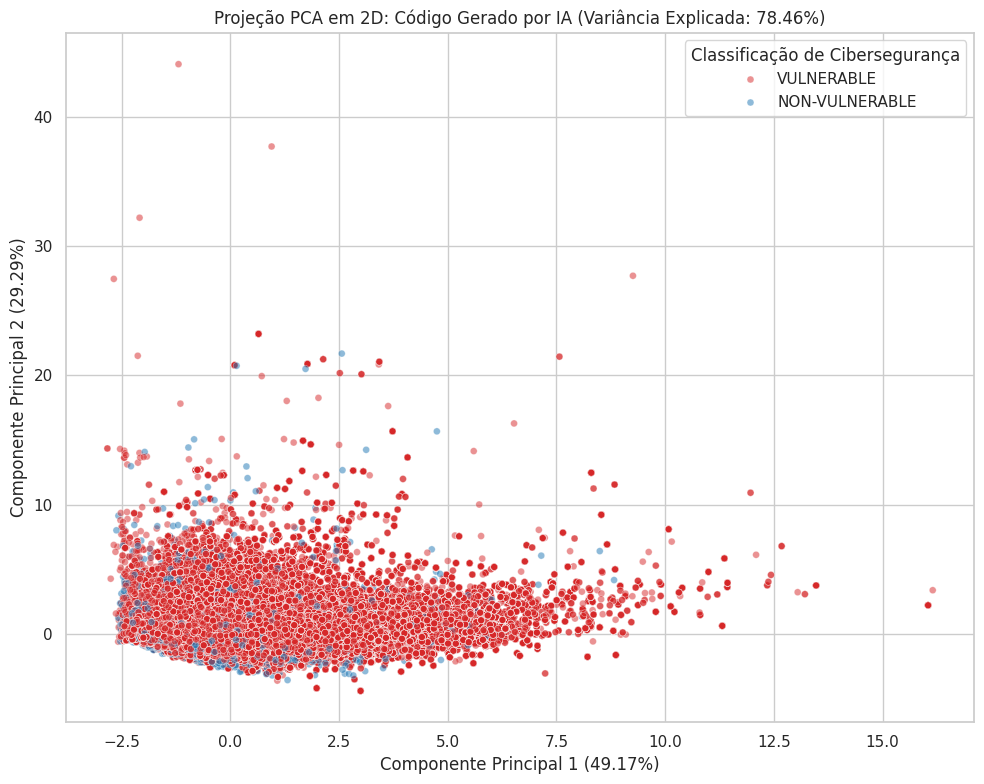

Processo finalizado! Arquivos salvos em:
- Dados: /home/deus/Documents/UEA/7_periodo/data_sci/pca_mds/ai-and-sec-issues_data-lake/src/03_gold/PCA/pca_results.parquet
- Imagem: /home/deus/Documents/UEA/7_periodo/data_sci/pca_mds/ai-and-sec-issues_data-lake/src/03_gold/PCA/pca_plot.png


In [44]:
print("Gerando e exportando o gráfico do PCA em PNG...")
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='category', 
    palette={'VULNERABLE': '#d62728', 'NON-VULNERABLE': '#1f77b4'}, 
    data=df_pca, 
    alpha=0.5, 
    s=25
)
plt.title(f'Projeção PCA em 2D: Código Gerado por IA (Variância Explicada: {var_explicada.sum()*100:.2f}%)')
plt.xlabel(f'Componente Principal 1 ({var_explicada[0]*100:.2f}%)')
plt.ylabel(f'Componente Principal 2 ({var_explicada[1]*100:.2f}%)')
plt.legend(title='Classificação de Cibersegurança')
plt.tight_layout()

# Salva a figura em alta resolução antes de fechar
plt.savefig(PCA_IMAGE_PATH, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"Processo finalizado! Arquivos salvos em:")
print(f"- Dados: {os.path.abspath(PCA_RESULTS_PATH)}")
print(f"- Imagem: {os.path.abspath(PCA_IMAGE_PATH)}")